# 23CSE301 Machine Learning - Capstone Project
## Track 1: Regression Track - BigMart Item Sales Prediction

This notebook implements a complete Machine Learning pipeline for predicting **BigMart Item Sales** (`Item_Outlet_Sales`)

---
## Step 1: Environment Setup & Library Imports
**Purpose**: Load essential Python libraries for data processing (`pandas`, `numpy`), visual analytics (`matplotlib`, `seaborn`), and machine learning model evaluation (`sklearn`), and set consistent visual styling.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('colorblind')

---
## Step 2: Dataset Loading & Audit (Section A1)
**Purpose**: Load the dataset and audit structural dimensions (`shape`), feature data types (`dtypes`), missing value counts, and baseline statistical properties of target variable `Item_Outlet_Sales`.

In [4]:
data_path = r'data/regression/data.csv'
df = pd.read_csv(data_path)

print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values Count:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nTarget Distribution Summary ('Item_Outlet_Sales'):")
print(df['Item_Outlet_Sales'].describe())




Dataset Shape: (14204, 13)

Data Types:
Item_Identifier                  str
Item_Weight                  float64
Item_Fat_Content                 str
Item_Visibility              float64
Item_Type                        str
Item_MRP                     float64
Outlet_Identifier                str
Outlet_Establishment_Year      int64
Outlet_Size                      str
Outlet_Location_Type             str
Outlet_Type                      str
Item_Outlet_Sales            float64
source                           str
dtype: object

Missing Values Count:
Item_Weight          2439
Outlet_Size          4016
Item_Outlet_Sales    5681
dtype: int64

Target Distribution Summary ('Item_Outlet_Sales'):
count     8523.000000
mean      2181.288914
std       1706.499616
min         33.290000
25%        834.247400
50%       1794.331000
75%       3101.296400
max      13086.964800
Name: Item_Outlet_Sales, dtype: float64


---
## Step 3: Exploratory Data Analysis (EDA) (Section A2 & A3)
**Purpose**: Perform exploratory visualizations analyzing target distribution skewness, feature-target correlations (`Item_MRP` and `Item_Visibility` vs sales), and sales variations across store outlet types.

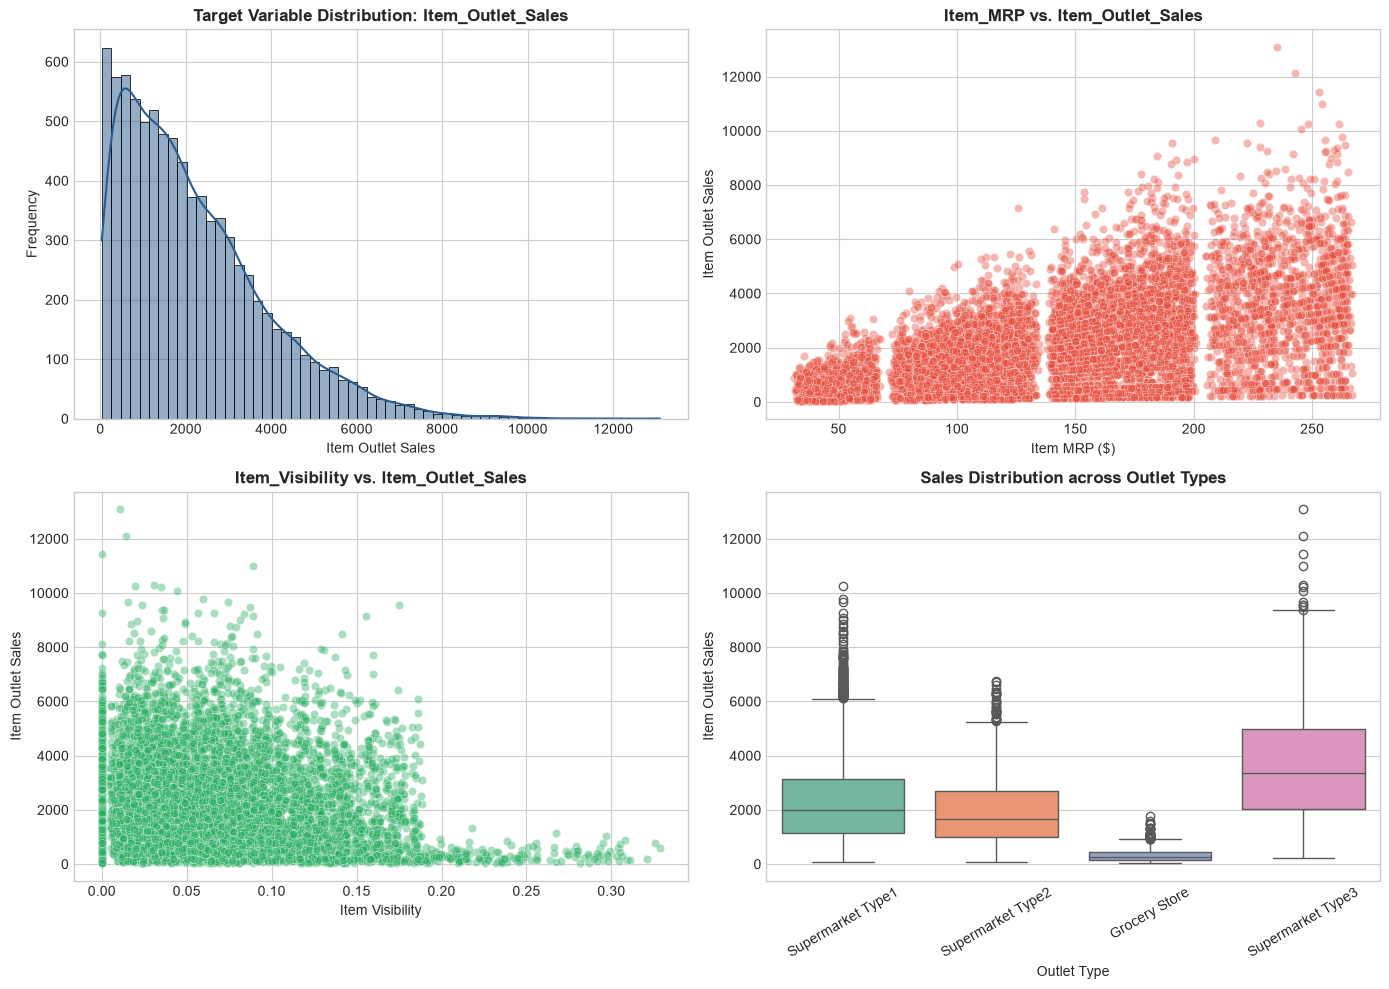

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target Distribution Plot
sns.histplot(df['Item_Outlet_Sales'].dropna(), kde=True, ax=axes[0, 0], color='#2b5c8f')
axes[0, 0].set_title('Target Variable Distribution: Item_Outlet_Sales', fontweight='bold')
axes[0, 0].set_xlabel('Item Outlet Sales')
axes[0, 0].set_ylabel('Frequency')

# 2. Item MRP vs Item Outlet Sales Scatter Plot
sns.scatterplot(data=df, x='Item_MRP', y='Item_Outlet_Sales', alpha=0.4, ax=axes[0, 1], color='#e74c3c')
axes[0, 1].set_title('Item_MRP vs. Item_Outlet_Sales', fontweight='bold')
axes[0, 1].set_xlabel('Item MRP ($)')
axes[0, 1].set_ylabel('Item Outlet Sales')

# 3. Item Visibility vs Item Outlet Sales Scatter Plot
sns.scatterplot(data=df, x='Item_Visibility', y='Item_Outlet_Sales', alpha=0.4, ax=axes[1, 0], color='#27ae60')
axes[1, 0].set_title('Item_Visibility vs. Item_Outlet_Sales', fontweight='bold')
axes[1, 0].set_xlabel('Item Visibility')
axes[1, 0].set_ylabel('Item Outlet Sales')

# 4. Sales by Outlet Type Boxplot
sns.boxplot(data=df, x='Outlet_Type', y='Item_Outlet_Sales', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Sales Distribution across Outlet Types', fontweight='bold')
axes[1, 1].set_xlabel('Outlet Type')
axes[1, 1].set_ylabel('Item Outlet Sales')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## Step 4: Preprocessing & Feature Engineering (Section B)
**Purpose**: Clean category redundancies, impute missing weights/sizes, treat zero visibilities, engineer new features (`Item_Category`, `Outlet_Age`), apply ordinal and one-hot encoding, execute 80:20 train-validation split (`random_state=42`), and fit standard scaling strictly on the training set to prevent data leakage.

In [6]:
# 1. Clean & Standardize Item_Fat_Content
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'})

# 2. Impute Missing Item_Weight (mean per Item_Identifier with global mean fallback)
df['Item_Weight'] = df.groupby('Item_Identifier')['Item_Weight'].transform(lambda x: x.fillna(x.mean()))
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

# 3. Impute Missing Outlet_Size (mode per Outlet_Type with 'Medium' fallback)
outlet_size_mode = df.groupby('Outlet_Type')['Outlet_Size'].apply(lambda x: x.mode()[0] if not x.mode().empty else 'Medium').to_dict()
df['Outlet_Size'] = df.apply(lambda x: outlet_size_mode[x['Outlet_Type']] if pd.isna(x['Outlet_Size']) else x['Outlet_Size'], axis=1)

# 4. Handle Item_Visibility 0 values
item_visibility_mean = df.groupby('Item_Identifier')['Item_Visibility'].mean()
df['Item_Visibility'] = df.apply(lambda x: item_visibility_mean[x['Item_Identifier']] if x['Item_Visibility'] == 0 else x['Item_Visibility'], axis=1)

# 5. Feature Engineering: Item_Category and Outlet_Age
df['Item_Category'] = df['Item_Identifier'].apply(lambda x: x[:2])
df.loc[df['Item_Category'] == 'NC', 'Item_Fat_Content'] = 'Non-Edible'
df['Outlet_Age'] = 2013 - df['Outlet_Establishment_Year']

# 6. Separate Train and Test subsets
train_df = df[df['source'] == 'train'].copy()
test_df = df[df['source'] == 'test'].copy()

# Drop identifier columns not used as direct features
drop_cols = ['Item_Identifier', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'source']
train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols + ['Item_Outlet_Sales'], inplace=True)

# 7. Ordinal Encoding
outlet_size_map = {'Small': 0, 'Medium': 1, 'High': 2}
outlet_location_map = {'Tier 1': 0, 'Tier 2': 1, 'Tier 3': 2}

train_df['Outlet_Size'] = train_df['Outlet_Size'].map(outlet_size_map).fillna(1).astype(int)
train_df['Outlet_Location_Type'] = train_df['Outlet_Location_Type'].map(outlet_location_map).fillna(1).astype(int)
test_df['Outlet_Size'] = test_df['Outlet_Size'].map(outlet_size_map).fillna(1).astype(int)
test_df['Outlet_Location_Type'] = test_df['Outlet_Location_Type'].map(outlet_location_map).fillna(1).astype(int)

# 8. One-Hot Encoding for Nominal Features
categorical_cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Type', 'Item_Category']
train_df = pd.get_dummies(train_df, columns=categorical_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=categorical_cols, drop_first=True)

# Align columns between train and test
train_cols = train_df.columns.drop('Item_Outlet_Sales')
for col in train_cols:
    if col not in test_df.columns:
        test_df[col] = 0
test_df = test_df[train_cols]

# Define Features and Target
X = train_df.drop('Item_Outlet_Sales', axis=1)
y = train_df['Item_Outlet_Sales']

# Train/Validation Split (80:20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit StandardScaler ONLY on X_train (No Data Leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
test_scaled = scaler.transform(test_df)

# Global results list to store metric evaluation for all 10 algorithms
results_list = []

print("Preprocessing complete!")
print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_val shape: {X_val_scaled.shape}")

Preprocessing complete!
X_train shape: (6818, 28)
X_val shape: (1705, 28)


---
## Step 5: Regression Model Training & Evaluation (Section C)

### Model 1: Linear Regression
**Purpose**: Fit an OLS baseline model to establish benchmark performance, compute mandatory metrics ($R^2$, RMSE, MAE, 5-Fold CV $R^2$), analyze coefficient weights to interpret key positive/negative sales drivers, and generate diagnostic plots.

 MODEL 1: LINEAR REGRESSION PERFORMANCE METRICS 
Validation R² Score     : 0.5785
Validation RMSE         : 1070.3835
Validation MAE          : 792.1043
5-Fold CV R² Mean Score : 0.5527 (+/- 0.0126)

Top 5 Positive Feature Coefficients (Sales Drivers):
                      Feature  Coefficient
Outlet_Type_Supermarket Type3  1050.829260
                     Item_MRP   979.458837
Outlet_Type_Supermarket Type1   880.763032
Outlet_Type_Supermarket Type2   444.129927
                  Outlet_Size    62.835101

Top 5 Negative Feature Coefficients (Sales Inhibitors):
              Feature  Coefficient
Item_Type_Soft Drinks    -6.772839
      Item_Visibility   -15.888133
 Outlet_Location_Type   -19.002917
      Item_Type_Dairy   -24.534209
           Outlet_Age   -68.635944


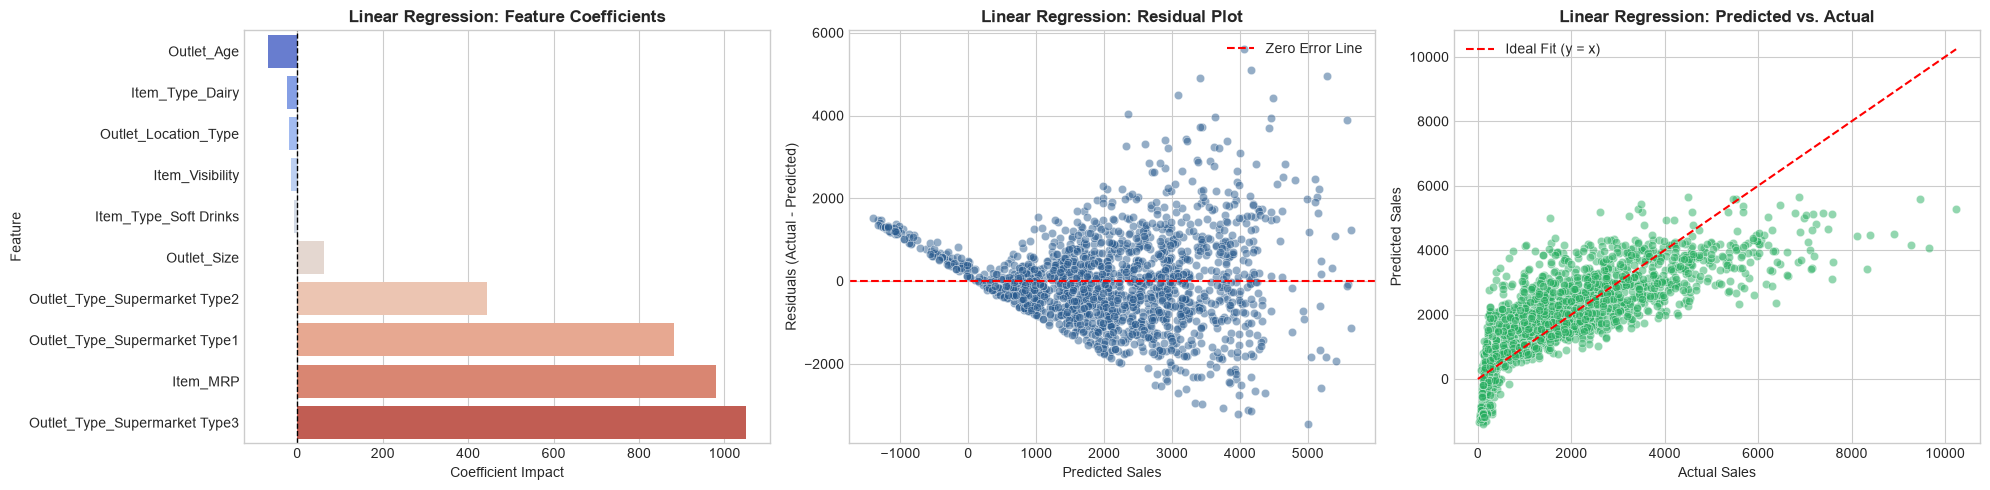

In [7]:
# 1. Initialize and Fit Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# 2. Generate Validation Predictions
y_pred_lr = lr_model.predict(X_val_scaled)

# 3. Calculate Evaluation Metrics
r2_lr = r2_score(y_val, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))
mae_lr = mean_absolute_error(y_val, y_pred_lr)

# 4. 5-Fold Cross-Validation R² Score
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores_lr = cross_val_score(lr_model, X_train_scaled, y_train, cv=kf, scoring='r2')
cv_r2_mean_lr = np.mean(cv_r2_scores_lr)
cv_r2_std_lr = np.std(cv_r2_scores_lr)

# 5. Record Results in Summary Table
results_list.append({
    'Algorithm': 'Linear Regression',
    'R2 Score': r2_lr,
    'RMSE': rmse_lr,
    'MAE': mae_lr,
    '5-Fold CV R2': cv_r2_mean_lr,
    '5-Fold CV Std': cv_r2_std_lr
})

# Display Metric Report
print("=" * 60)
print(" MODEL 1: LINEAR REGRESSION PERFORMANCE METRICS ")
print("=" * 60)
print(f"Validation R² Score     : {r2_lr:.4f}")
print(f"Validation RMSE         : {rmse_lr:.4f}")
print(f"Validation MAE          : {mae_lr:.4f}")
print(f"5-Fold CV R² Mean Score : {cv_r2_mean_lr:.4f} (+/- {cv_r2_std_lr:.4f})")
print("=" * 60)

# 6. Coefficient Analysis & Interpretation
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\nTop 5 Positive Feature Coefficients (Sales Drivers):")
print(coef_df.head(5).to_string(index=False))

print("\nTop 5 Negative Feature Coefficients (Sales Inhibitors):")
print(coef_df.tail(5).to_string(index=False))

# 7. Model Visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot A: Feature Coefficients
top_bottom_coefs = pd.concat([coef_df.head(5), coef_df.tail(5)]).sort_values(by='Coefficient')
sns.barplot(data=top_bottom_coefs, x='Coefficient', y='Feature', ax=axes[0], palette='coolwarm')
axes[0].set_title('Linear Regression: Feature Coefficients', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coefficient Impact')
axes[0].set_ylabel('Feature')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)

# Plot B: Residual Plot
residuals = y_val - y_pred_lr
sns.scatterplot(x=y_pred_lr, y=residuals, alpha=0.5, ax=axes[1], color='#2b5c8f')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error Line')
axes[1].set_title('Linear Regression: Residual Plot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].legend(loc='upper right')

# Plot C: Predicted vs Actual Plot
sns.scatterplot(x=y_val, y=y_pred_lr, alpha=0.5, ax=axes[2], color='#27ae60')
max_val = max(y_val.max(), y_pred_lr.max())
axes[2].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Ideal Fit (y = x)')
axes[2].set_title('Linear Regression: Predicted vs. Actual', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Actual Sales')
axes[2].set_ylabel('Predicted Sales')
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()

### Model 2: Ridge Regression

### Model 3: Lasso Regression

### Model 4: ElasticNet Regression

### Model 5: Polynomial Regression

### Model 6: Decision Tree Regressor

 DECISION TREE REGRESSOR PERFORMANCE METRICS 
Validation R² Score     : 0.6048
Validation RMSE         : 1036.4433
Validation MAE          : 723.4958
5-Fold CV R² Mean Score : 0.5815 (+/- 0.0174)

Top 5 Important Features:
                      Feature  Importance
                     Item_MRP    0.545188
Outlet_Type_Supermarket Type3    0.179954
Outlet_Type_Supermarket Type1    0.160523
                  Outlet_Size    0.093877
                   Outlet_Age    0.016297


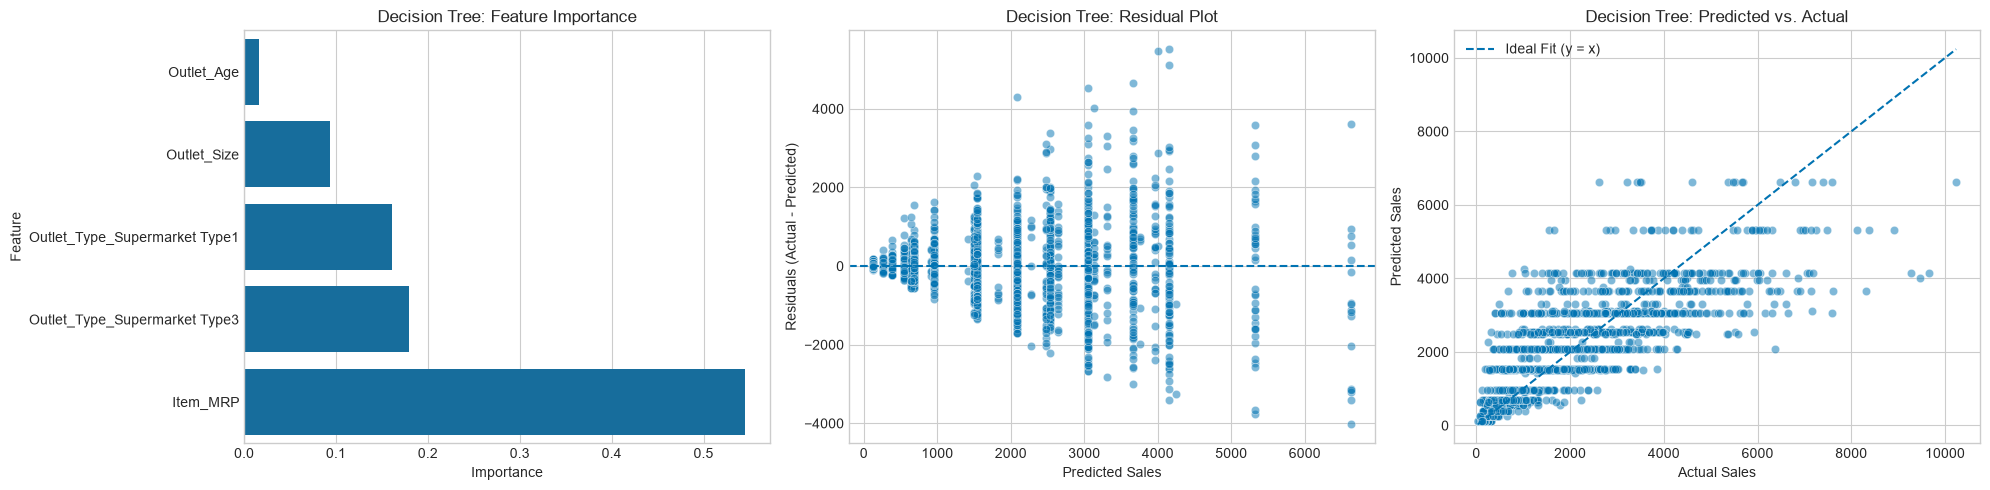

In [8]:
decision_tree = DecisionTreeRegressor(max_depth=5, min_samples_split=2, min_samples_leaf=5, random_state=42)

decision_tree.fit(X_train_scaled, y_train)

predicted_sales = decision_tree.predict(X_val_scaled)

r2_score_dt = r2_score(y_val, predicted_sales)
rmse_dt = np.sqrt(mean_squared_error(y_val, predicted_sales))
mae_dt = mean_absolute_error(y_val, predicted_sales)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(decision_tree, X_train_scaled, y_train, cv=kf, scoring='r2')

average_cv_r2 = np.mean(cv_scores)
std_cv_r2 = np.std(cv_scores)

results_list.append({
    'Algorithm': 'Decision Tree Regressor',
    'R2 Score': r2_score_dt,
    'RMSE': rmse_dt,
    'MAE': mae_dt,
    '5-Fold CV R2': average_cv_r2,
    '5-Fold CV Std': std_cv_r2
})

print("=" * 60)
print(" DECISION TREE REGRESSOR PERFORMANCE METRICS ")
print("=" * 60)
print(f"Validation R² Score     : {r2_score_dt:.4f}")
print(f"Validation RMSE         : {rmse_dt:.4f}")
print(f"Validation MAE          : {mae_dt:.4f}")
print(f"5-Fold CV R² Mean Score : {average_cv_r2:.4f} (+/- {std_cv_r2:.4f})")
print("=" * 60)


feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': decision_tree.feature_importances_}).sort_values(by='Importance', ascending=False)

print("\nTop 5 Important Features:")
print(feature_importance.head(5).to_string(index=False))


fig, axes = plt.subplots(1, 3, figsize=(20, 5))

top_features = feature_importance.head(5).sort_values(by='Importance')

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature',
    ax=axes[0]
)

axes[0].set_title('Decision Tree: Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Feature')


residuals = y_val - predicted_sales

sns.scatterplot(
    x=predicted_sales,
    y=residuals,
    alpha=0.5,
    ax=axes[1]
)

axes[1].axhline(0, linestyle='--')
axes[1].set_title('Decision Tree: Residual Plot')
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residuals (Actual - Predicted)')


sns.scatterplot(
    x=y_val,
    y=predicted_sales,
    alpha=0.5,
    ax=axes[2]
)

minimum = min(y_val.min(), predicted_sales.min())
maximum = max(y_val.max(), predicted_sales.max())

axes[2].plot(
    [minimum, maximum],
    [minimum, maximum],
    '--',
    linewidth=1.5,
    label='Ideal Fit (y = x)'
)

axes[2].set_title('Decision Tree: Predicted vs. Actual')
axes[2].set_xlabel('Actual Sales')
axes[2].set_ylabel('Predicted Sales')
axes[2].legend()

plt.tight_layout()
plt.show()

Hyperparameter tuning for decision tree regressor

In [9]:
mdv = [5, 10, 15, 20]
minsamples_splitvals = [2, 5, 10]
minsamples_leafvals = [1, 2, 5]

results = []

for max_depth in mdv:
    for min_samples_split in minsamples_splitvals:
        for min_samples_leaf in minsamples_leafvals:

            model = DecisionTreeRegressor(
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                random_state=42
            )

            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_val_scaled)

            r2 = r2_score(y_val, y_pred)

            results.append({
                'max_depth': max_depth,
                'min_samples_split': min_samples_split,
                'min_samples_leaf': min_samples_leaf,
                'R2 Score': r2
            })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='R2 Score', ascending=False)

print("Decision Tree Hyperparameter Results:")
print(results_df.to_string(index=False))

print("\nBest Combination:")
print(results_df.iloc[0])

Decision Tree Hyperparameter Results:
 max_depth  min_samples_split  min_samples_leaf  R2 Score
         5                  2                 5  0.604773
         5                  5                 5  0.604773
         5                 10                 5  0.604773
         5                  2                 1  0.598271
         5                  5                 1  0.598271
         5                  2                 2  0.598271
         5                 10                 1  0.598271
         5                  5                 2  0.598271
         5                 10                 2  0.598271
        10                  2                 5  0.542844
        10                 10                 5  0.542844
        10                  5                 5  0.542844
        10                 10                 2  0.505723
        10                 10                 1  0.500715
        10                  5                 2  0.497853
        10                  5     

Best Combination:
- max_depth            5.000000
- min_samples_split    2.000000
- min_samples_leaf     5.000000

### Model 7: Random Forest Regressor

 RANDOM FOREST REGRESSOR PERFORMANCE METRICS 
Validation R² Score     : 0.6185
Validation RMSE         : 1018.2291
Validation MAE          : 713.2050
5-Fold CV R² Mean Score : 0.5920 (+/- 0.0154)

Top 5 Important Features:
                      Feature  Importance
                     Item_MRP    0.544788
Outlet_Type_Supermarket Type3    0.176268
Outlet_Type_Supermarket Type1    0.158948
                  Outlet_Size    0.036811
                   Outlet_Age    0.036393


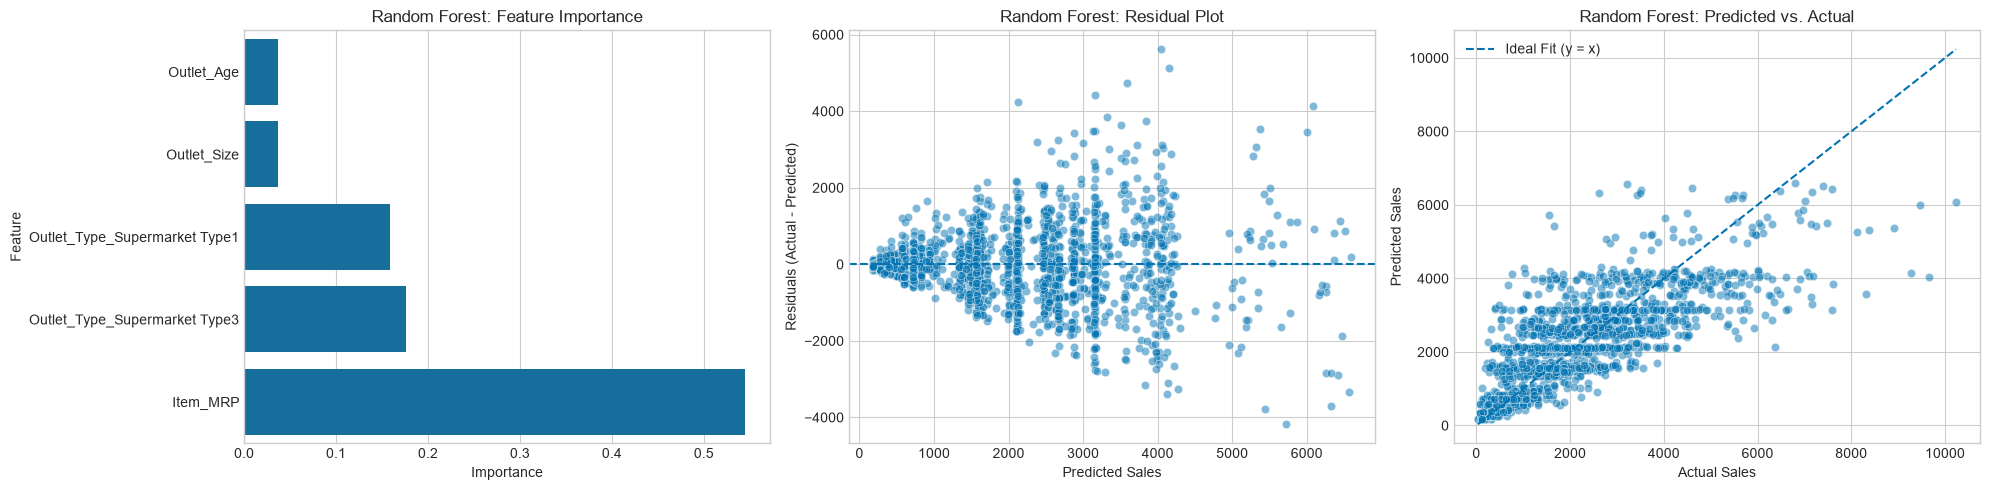

In [14]:
random_forest = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=5,
    random_state=42
)

random_forest.fit(X_train_scaled, y_train)

predicted_sales = random_forest.predict(X_val_scaled)

r2_score_rf = r2_score(y_val, predicted_sales)
rmse_rf = np.sqrt(mean_squared_error(y_val, predicted_sales))
mae_rf = mean_absolute_error(y_val, predicted_sales)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    random_forest,
    X_train_scaled,
    y_train,
    cv=kf,
    scoring='r2'
)

average_cv_r2 = np.mean(cv_scores)
std_cv_r2 = np.std(cv_scores)

results_list.append({
    'Algorithm': 'Random Forest Regressor',
    'R2 Score': r2_score_rf,
    'RMSE': rmse_rf,
    'MAE': mae_rf,
    '5-Fold CV R2': average_cv_r2,
    '5-Fold CV Std': std_cv_r2
})

print("=" * 60)
print(" RANDOM FOREST REGRESSOR PERFORMANCE METRICS ")
print("=" * 60)
print(f"Validation R² Score     : {r2_score_rf:.4f}")
print(f"Validation RMSE         : {rmse_rf:.4f}")
print(f"Validation MAE          : {mae_rf:.4f}")
print(f"5-Fold CV R² Mean Score : {average_cv_r2:.4f} (+/- {std_cv_r2:.4f})")
print("=" * 60)


feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': random_forest.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 5 Important Features:")
print(feature_importance.head(5).to_string(index=False))


fig, axes = plt.subplots(1, 3, figsize=(20, 5))

top_features = feature_importance.head(5).sort_values(by='Importance')

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature',
    ax=axes[0]
)

axes[0].set_title('Random Forest: Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Feature')


residuals = y_val - predicted_sales

sns.scatterplot(
    x=predicted_sales,
    y=residuals,
    alpha=0.5,
    ax=axes[1]
)

axes[1].axhline(0, linestyle='--')
axes[1].set_title('Random Forest: Residual Plot')
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residuals (Actual - Predicted)')


sns.scatterplot(
    x=y_val,
    y=predicted_sales,
    alpha=0.5,
    ax=axes[2]
)

minimum = min(y_val.min(), predicted_sales.min())
maximum = max(y_val.max(), predicted_sales.max())

axes[2].plot(
    [minimum, maximum],
    [minimum, maximum],
    '--',
    linewidth=1.5,
    label='Ideal Fit (y = x)'
)

axes[2].set_title('Random Forest: Predicted vs. Actual')
axes[2].set_xlabel('Actual Sales')
axes[2].set_ylabel('Predicted Sales')
axes[2].legend()

plt.tight_layout()
plt.show()

### Model 8: Gradient Boosting Regressor

### Model 9: Support Vector Regressor (SVR)

### Model 10: K-Nearest Neighbors Regressor

---
## Step 6: Model Comparison & Results Summary (Section C2)

In [11]:
if results_list:
    summary_df = pd.DataFrame(results_list).sort_values(by='R2 Score', ascending=False)
    display(summary_df)
else:
    print("No models trained yet.")

,Algorithm,R2 Score,RMSE,MAE,5-Fold CV R2,5-Fold CV Std
2,Random Forest Regressor,0.608831,1031.108885,720.045419,0.577742,0.020550
1,Decision Tree Regressor,0.604773,1036.443343,723.495789,0.581493,0.017366
0,Linear Regression,0.578464,1070.383530,792.104274,0.552705,0.012584


---
## Step 7: Best Model Export & Pipeline Serialization (Section 8)

In [12]:
import joblib

# Example: Export best model after full model evaluation
# joblib.dump(best_model, '../models/regression_model.pkl')
print("Model serialization setup complete.")

Model serialization setup complete.
